## Daily Weather from Top 10 Major Indian Cities, 2000-2024
### Detailed EDA at Year Level

#### Import Libraries and set path

In [3]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator

In [4]:
path = r'C:\Users\artoe\Documents\DataAnalytics\projects\india weather'

#### Import data as pickle

In [6]:
df = pd.read_pickle(os.path.join(path, 'data', 'daily_weather_updated.pkl'))

### Create Subsets for Selected Years

In [8]:
df.dtypes

city                                      object
date                              datetime64[ns]
temperature_2m_max                       float64
temperature_2m_min                       float64
apparent_temperature_max                 float64
apparent_temperature_min                 float64
precipitation_sum                        float64
rain_sum                                 float64
weather_code                               int64
wind_speed_10m_max                       float64
wind_gusts_10m_max                       float64
wind_direction_10m_dominant                int64
wmo_description                           object
temperature_2m_mean                      float64
apparent_temperature_mean                float64
year                                       int32
month                                      int32
month_year                                object
min_temp_monthly_avg                     float64
max_temp_monthly_avg                     float64
mean_temp_monthly_av

In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
df['year'], df['month'] = df['date'].dt.year, df['date'].dt.month

In [11]:
df.dtypes

city                                      object
date                              datetime64[ns]
temperature_2m_max                       float64
temperature_2m_min                       float64
apparent_temperature_max                 float64
apparent_temperature_min                 float64
precipitation_sum                        float64
rain_sum                                 float64
weather_code                               int64
wind_speed_10m_max                       float64
wind_gusts_10m_max                       float64
wind_direction_10m_dominant                int64
wmo_description                           object
temperature_2m_mean                      float64
apparent_temperature_mean                float64
year                                       int32
month                                      int32
month_year                                object
min_temp_monthly_avg                     float64
max_temp_monthly_avg                     float64
mean_temp_monthly_av

In [12]:
#create a subset for each year
df_2000 =  df[df['year']==2000]
df_2012 =  df[df['year']==2012]
df_2024 =  df[df['year']==2024]

### EDA for Year 2000 (All Cities)

#### Daily Minimum and Maximum Temperatures

In [15]:
melted_minmax_2000 = df_2000.melt(
    id_vars=['date'],
    value_vars=['temperature_2m_min', 'temperature_2m_max'],
    var_name='Temp_Type',
    value_name='Temp',
)

In [16]:
melted_minmax_2000['Temp_Type'] = melted_minmax_2000['Temp_Type'].replace(
    {'temperature_2m_min': 'Daily Minimum', 'temperature_2m_max': 'Daily Maximum'}
)

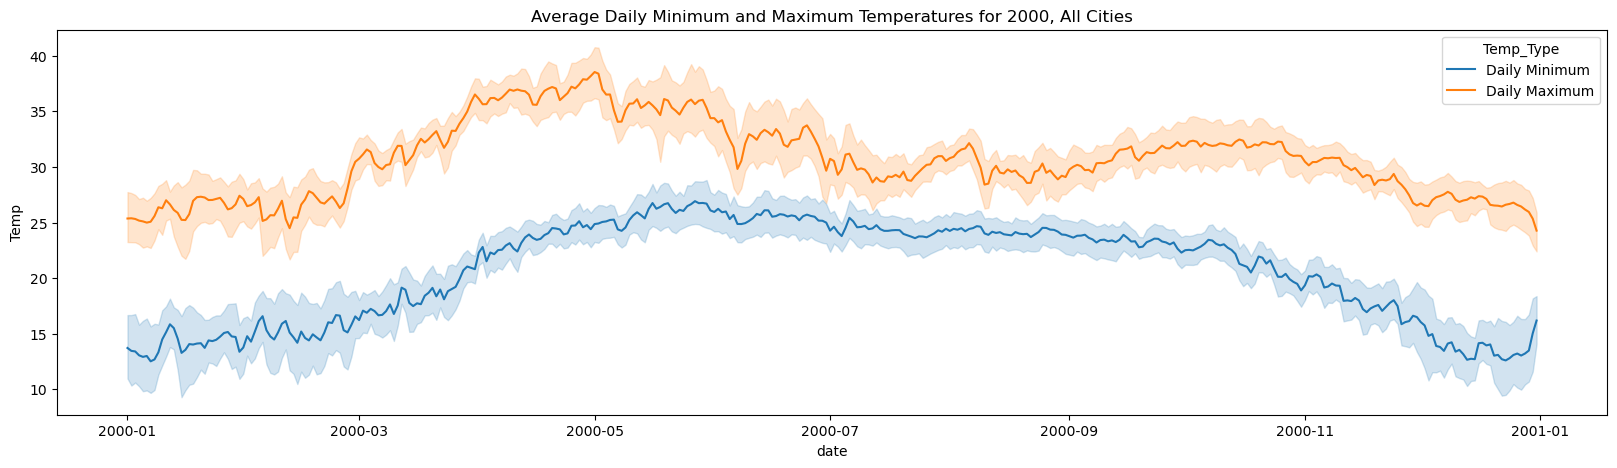

In [17]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_2000, x='date', y='Temp', hue='Temp_Type')
#ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Average Daily Minimum and Maximum Temperatures for 2000, All Cities')
plt.show()

In [18]:
fig.savefig(os.path.join(path, 'visualizations','temps_minmax_allcities_2000.png'))

#### Daily Mean and Perceived Daily Mean Temperatures

In [20]:
melted_temps_2000 = df_2000.melt(
    id_vars='date',
    value_vars=['temperature_2m_mean', 'apparent_temperature_mean'],
    var_name="Temp_Type",
    value_name="Mean_Temp",
)

In [21]:
melted_temps_2000["Temp_Type"] = melted_temps_2000["Temp_Type"].replace(
    {'temperature_2m_mean': "Daily Mean Temp (C)", 'apparent_temperature_mean': "Perceived Daily Mean Temp (C)"}
)

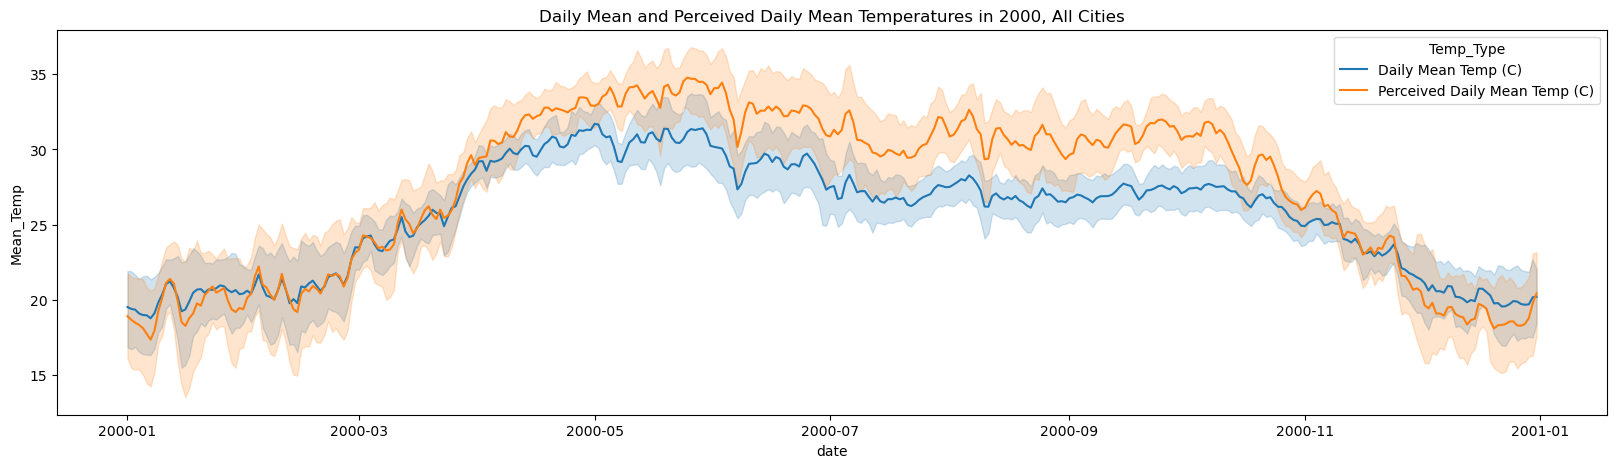

In [22]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_temps_2000, x='date', y='Mean_Temp', hue='Temp_Type')
plt.title('Daily Mean and Perceived Daily Mean Temperatures in 2000, All Cities')
plt.show()

In [23]:
fig.savefig(os.path.join(path, 'visualizations','temps_real_perceived_allcities_2000.png'))

### Observations

Perceived temperature tends to be lower during the winter months and higher between spring and fall.

Perceived daily means went as low as below 15 degrees celsius and as high as above 35 degrees.

Between July and September there was an overall drop in both measured temperatures, with perceived temperatures being significantly lower. This is likely due to the monsoon taking place in most of the cities at this time.

#### Daily Precipitation Levels (Monthly Average)

In [26]:
melted_prec_2000 = df_2000.melt(
    id_vars='date',
    value_vars=['precipitation_sum', 'rain_sum'],
    var_name='precipitation_type',
    value_name='precipitation_level',
)

In [27]:
melted_prec_2000['precipitation_type'] = melted_prec_2000['precipitation_type'].replace(
    {'precipitation_sum': 'Average Daily Precipitation', 'rain_sum': 'Average Daily Rain'}
)

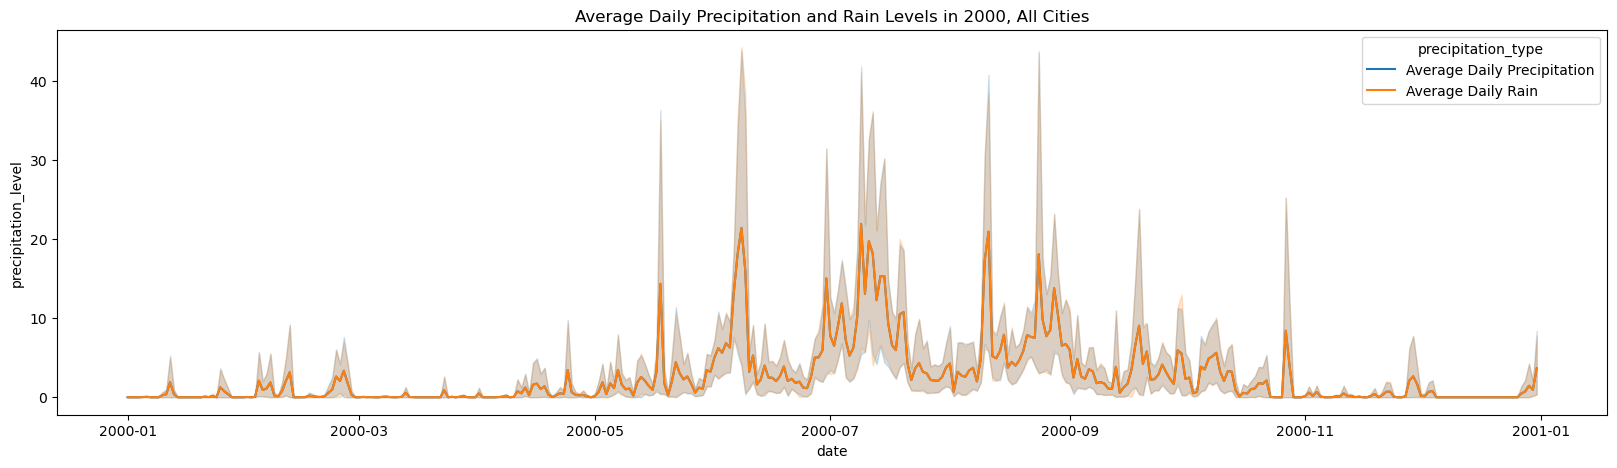

In [28]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_prec_2000, x='date', y='precipitation_level', hue='precipitation_type')
plt.title('Average Daily Precipitation and Rain Levels in 2000, All Cities')
plt.show()

In [29]:
fig.savefig(os.path.join(path, 'visualizations','rain_allcities_2000.png'))

### Observations

Precipitation peaks betweem June and September, with a break between July and August.

Late October shows a slight peak in precipitation, indicating that some of the cities experience a second or delayed rainy season at this time.

#### Daily Maximum Wind Speed and Wind Gusts + Wind Direction

In [32]:
melted_wind_2000 = df_2000.melt(
    id_vars='date',
    value_vars=['wind_speed_10m_max', 'wind_gusts_10m_max'],
    var_name='wind_measure',
    value_name='wind_speed',
)

In [33]:
melted_wind_2000['wind_measure'] = melted_wind_2000['wind_measure'].replace(
    {'wind_speed_10m_max': 'Maximum Daily Wind Speed (km/h)', 'wind_gusts_10m_max': 'Maximum Daily Wind Gusts (km/h)'}
)

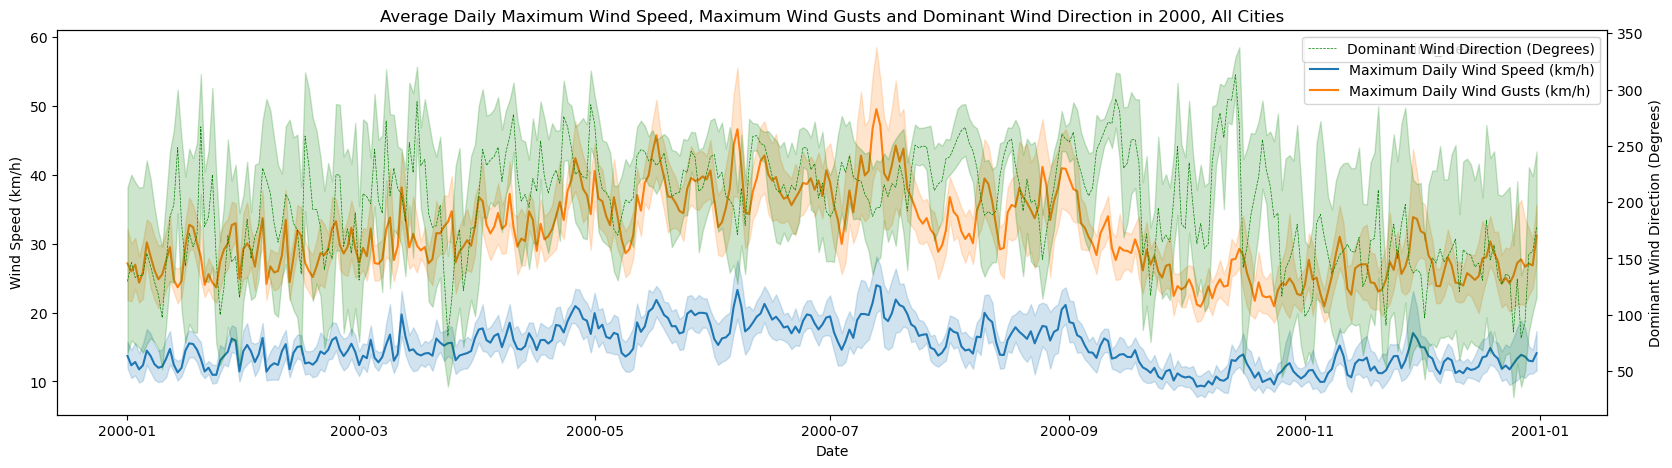

In [34]:
fig, ax1 = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_wind_2000, x='date', y='wind_speed', hue='wind_measure')

ax1.set_ylabel('Wind Speed (km/h)')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.set_ylabel('Dominant Wind Direction (Degrees)')
sns.lineplot(
    data=df_2000,
    x='date',
    y='wind_direction_10m_dominant',
    color='green',
    linestyle='--',
    linewidth=0.5,
    label='Dominant Wind Direction (Degrees)',
    ax=ax2,
    
)
fig.align_ylabels()
plt.title('Average Daily Maximum Wind Speed, Maximum Wind Gusts and Dominant Wind Direction in 2000, All Cities')
plt.show()

In [35]:
fig.savefig(os.path.join(path, 'visualizations','wind_allcities_2000.png'))

### Observations

Wind speed and wind gusts peak during the summer months.

During this time, wind direction appears to be between 25 and 45 degrees.

### EDA for Year 2012 (All Cities)

#### Daily Minimum and Maximum Temperatures

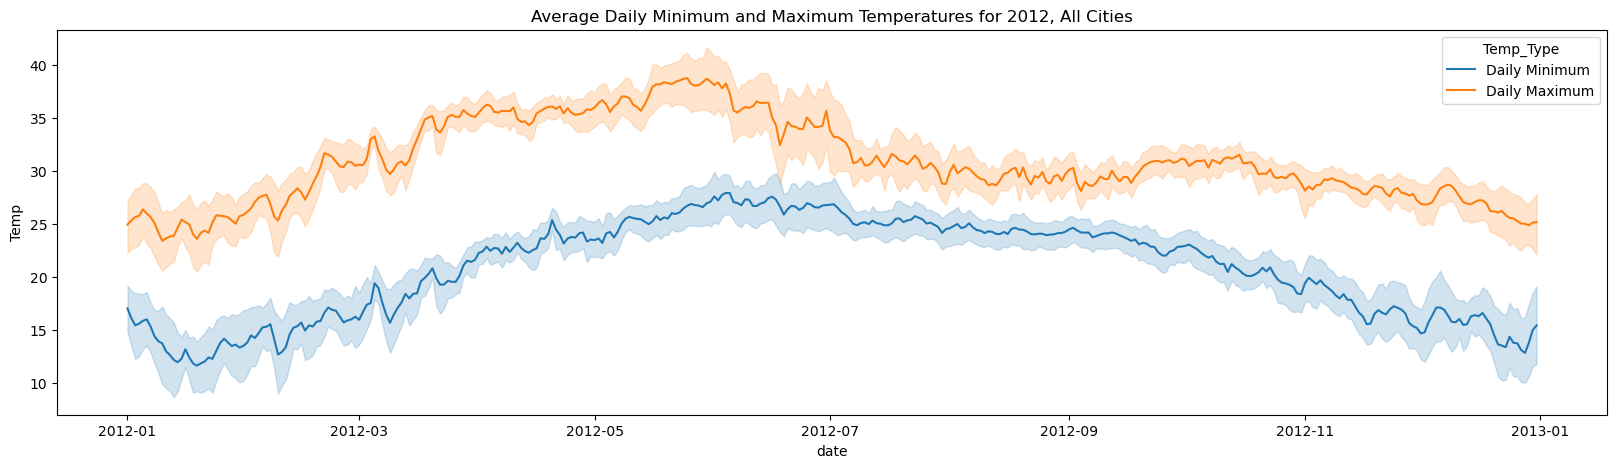

In [39]:
melted_minmax_2012 = df_2012.melt(
    id_vars=['date'],
    value_vars=['temperature_2m_min', 'temperature_2m_max'],
    var_name='Temp_Type',
    value_name='Temp',
)

melted_minmax_2012['Temp_Type'] = melted_minmax_2012['Temp_Type'].replace(
    {'temperature_2m_min': 'Daily Minimum', 'temperature_2m_max': 'Daily Maximum'}
)

fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_2012, x='date', y='Temp', hue='Temp_Type')
plt.title('Average Daily Minimum and Maximum Temperatures for 2012, All Cities')
plt.show()

In [40]:
fig.savefig(os.path.join(path, 'visualizations','temps_minmax_allcities_2012.png'))

### Observations

Daily minimums went as low as under 10 degrees between January and March 2012, while daily maximums peaked between May and July, with some cities reaching above 40 degrees.

#### Daily Mean and Perceived Daily Mean Temperatures

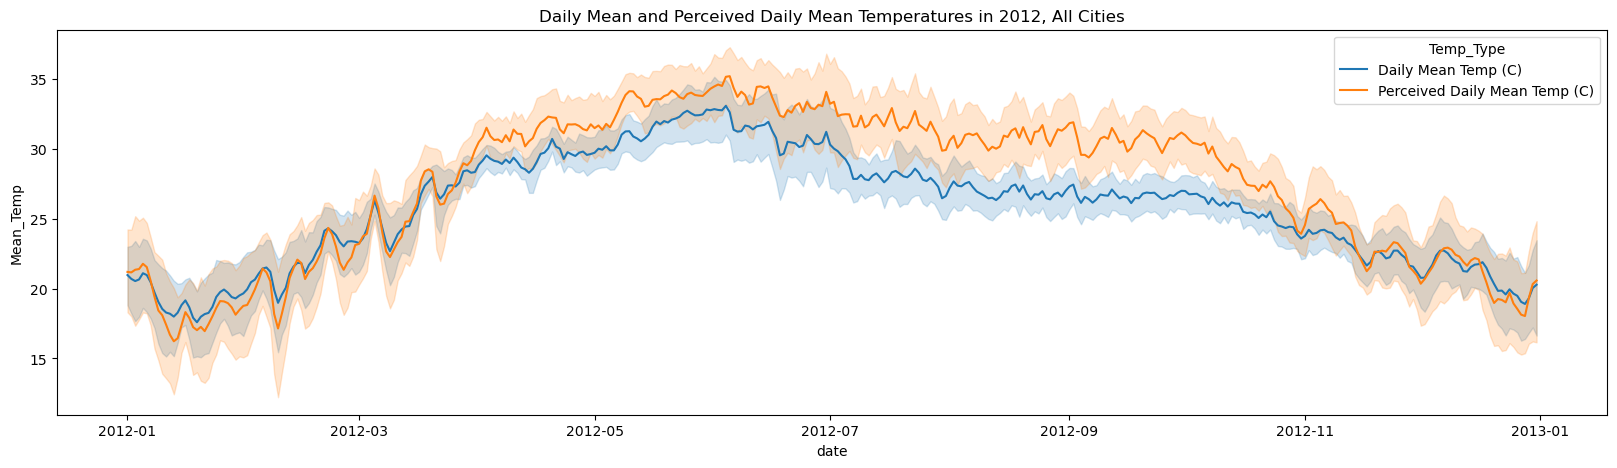

In [43]:
melted_temps_2012 = df_2012.melt(
    id_vars='date',
    value_vars=['temperature_2m_mean', 'apparent_temperature_mean'],
    var_name='Temp_Type',
    value_name='Mean_Temp',
)

melted_temps_2012['Temp_Type'] = melted_temps_2012['Temp_Type'].replace(
    {'temperature_2m_mean': 'Daily Mean Temp (C)', 'apparent_temperature_mean': 'Perceived Daily Mean Temp (C)'}
)

fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_temps_2012, x='date', y='Mean_Temp', hue='Temp_Type')
plt.title('Daily Mean and Perceived Daily Mean Temperatures in 2012, All Cities')
plt.show()

In [44]:
fig.savefig(os.path.join(path, 'visualizations','temps_real_perceived_allcities_2012.png'))

#### Daily Precipitation Levels (Monthly Average)

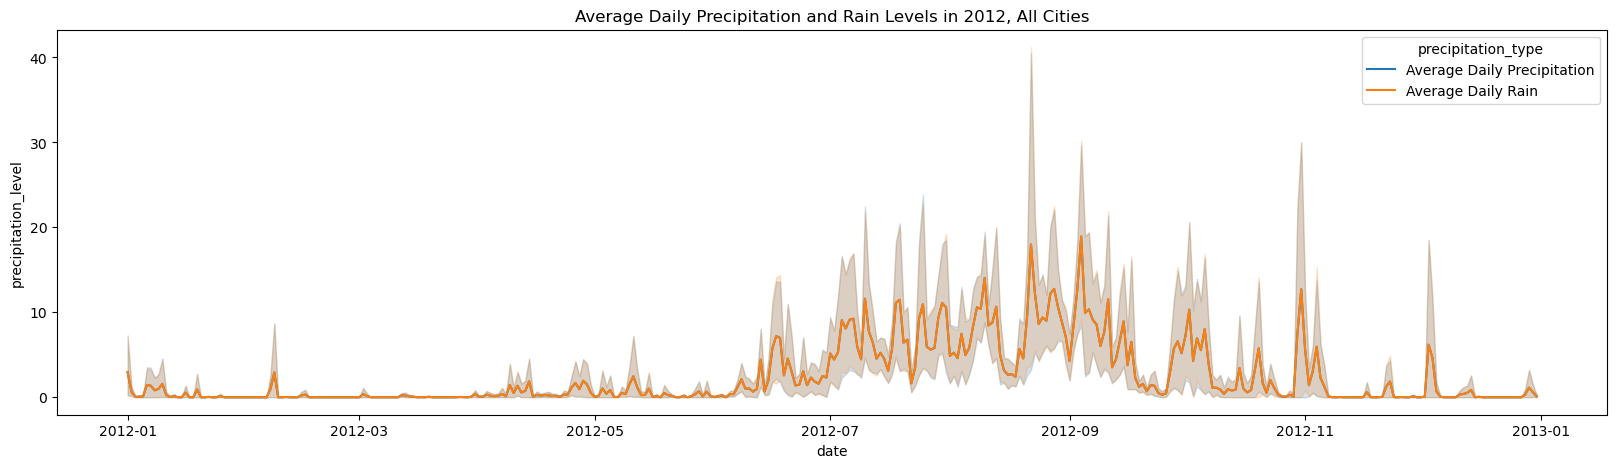

In [46]:
melted_prec_2012 = df_2012.melt(
    id_vars='date',
    value_vars=['precipitation_sum', 'rain_sum'],
    var_name='precipitation_type',
    value_name='precipitation_level',
)

melted_prec_2012['precipitation_type'] = melted_prec_2012['precipitation_type'].replace(
    {'precipitation_sum': 'Average Daily Precipitation', 'rain_sum': 'Average Daily Rain'}
)

fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_prec_2012, x='date', y='precipitation_level', hue='precipitation_type')
plt.title('Average Daily Precipitation and Rain Levels in 2012, All Cities')
plt.show()

In [47]:
fig.savefig(os.path.join(path, 'visualizations','rain_allcities_2012.png'))

#### Daily Maximum Wind Speed and Wind Gusts + Wind Direction

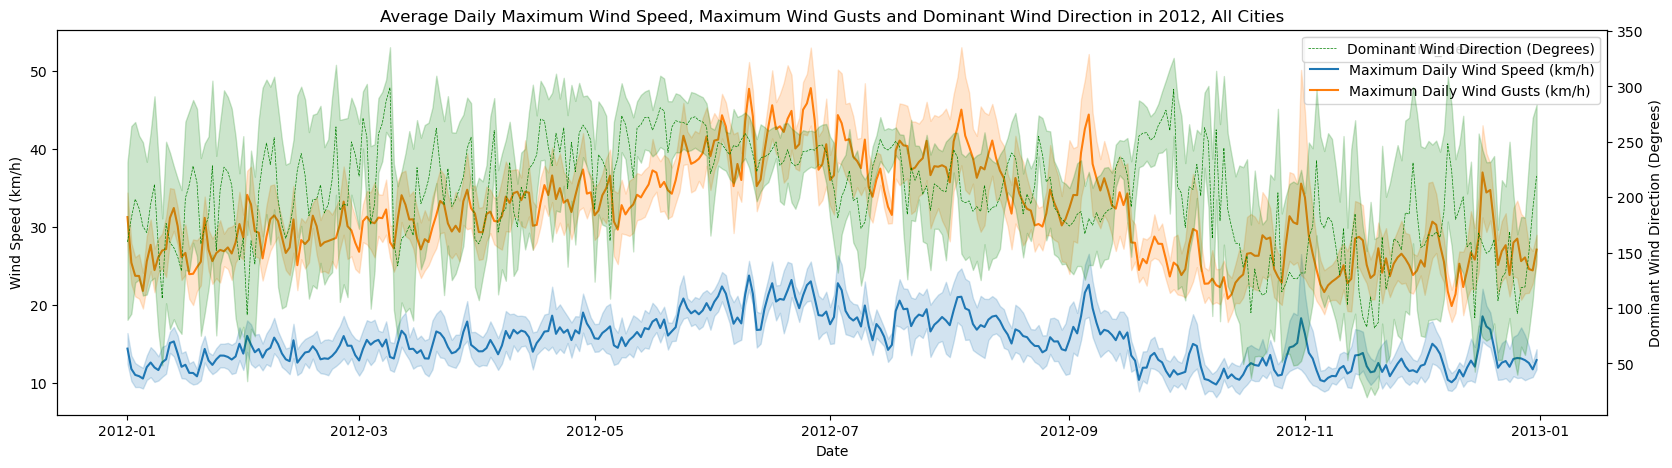

In [49]:
melted_wind_2012 = df_2012.melt(
    id_vars='date',
    value_vars=['wind_speed_10m_max', 'wind_gusts_10m_max'],
    var_name='wind_measure',
    value_name='wind_speed',
)

melted_wind_2012['wind_measure'] = melted_wind_2012['wind_measure'].replace(
    {'wind_speed_10m_max': 'Maximum Daily Wind Speed (km/h)', 'wind_gusts_10m_max': 'Maximum Daily Wind Gusts (km/h)'}
)

fig, ax1 = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_wind_2012, x='date', y='wind_speed', hue='wind_measure')

ax1.set_ylabel('Wind Speed (km/h)')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.set_ylabel('Dominant Wind Direction (Degrees)')
sns.lineplot(
    data=df_2012,
    x='date',
    y='wind_direction_10m_dominant',
    color='green',
    linestyle='--',
    linewidth=0.5,
    label='Dominant Wind Direction (Degrees)',
    ax=ax2,
    
 )
fig.align_ylabels()
plt.title('Average Daily Maximum Wind Speed, Maximum Wind Gusts and Dominant Wind Direction in 2012, All Cities')
plt.show()

In [50]:
fig.savefig(os.path.join(path, 'visualizations','wind_allcities_2012.png'))

### EDA for Year 2024 (All Cities)

#### Daily Minimum and Maximum Temperatures

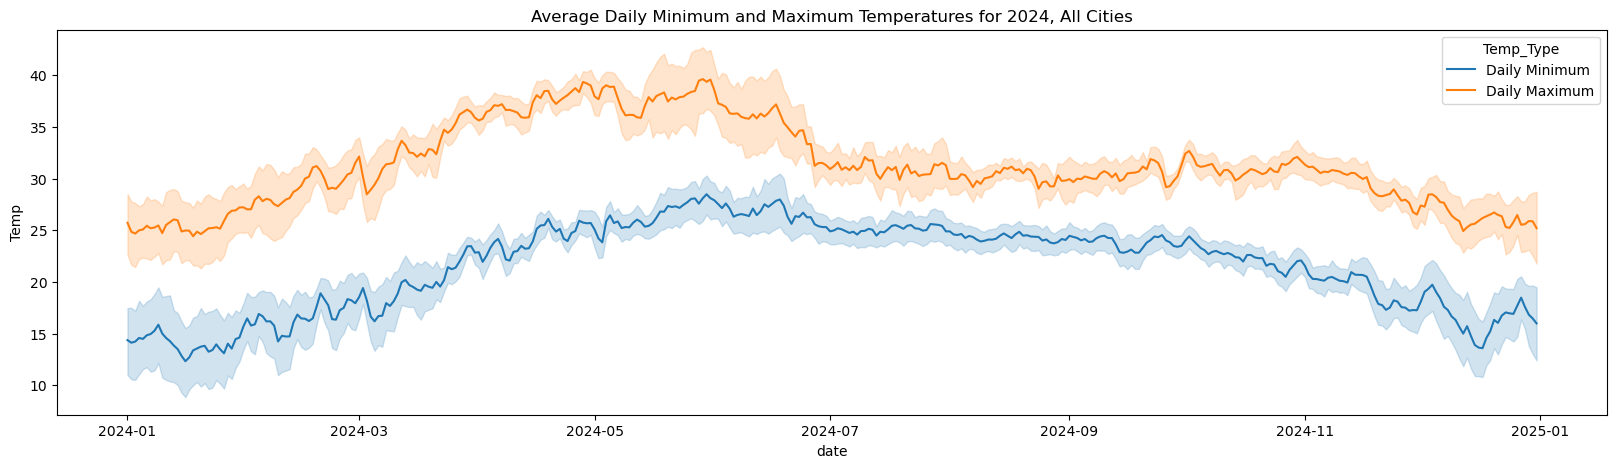

In [53]:
melted_minmax_2024 = df_2024.melt(
    id_vars=['date'],
    value_vars=['temperature_2m_min', 'temperature_2m_max'],
    var_name='Temp_Type',
    value_name='Temp',
)

melted_minmax_2024['Temp_Type'] = melted_minmax_2024['Temp_Type'].replace(
    {'temperature_2m_min': 'Daily Minimum', 'temperature_2m_max': 'Daily Maximum'}
)

fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_2024, x='date', y='Temp', hue='Temp_Type')
plt.title('Average Daily Minimum and Maximum Temperatures for 2024, All Cities')
plt.show()

In [54]:
fig.savefig(os.path.join(path, 'visualizations','temps_minmax_allcities_2024.png'))

#### Daily Mean and Perceived Daily Mean Temperatures

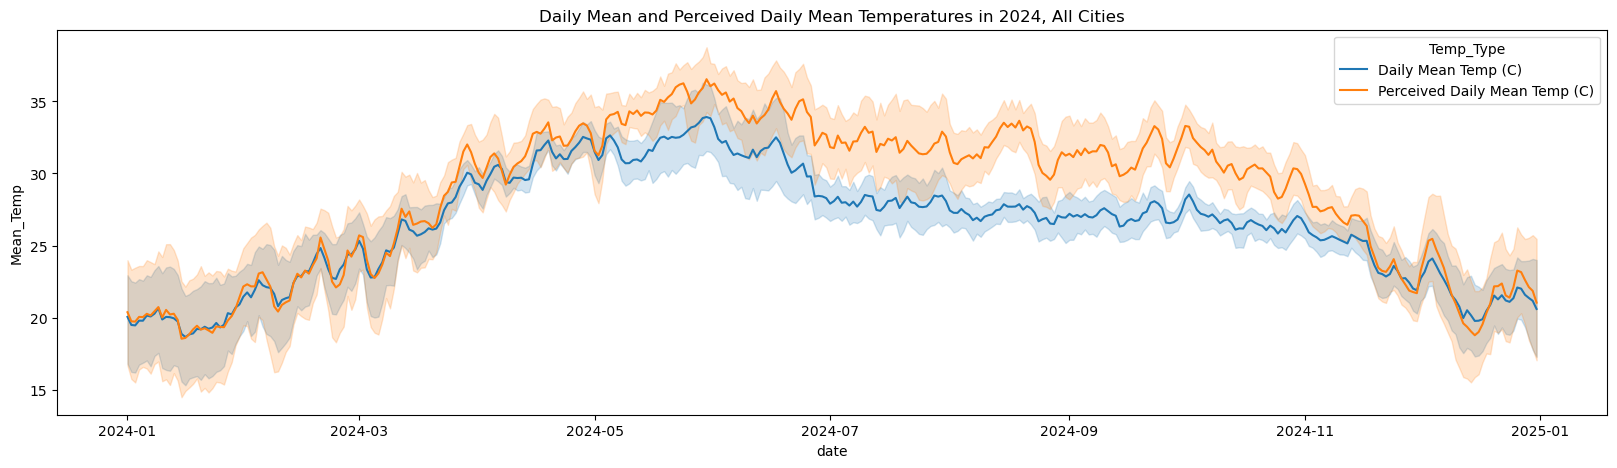

In [56]:
melted_temps_2024 = df_2024.melt(
    id_vars='date',
    value_vars=['temperature_2m_mean', 'apparent_temperature_mean'],
    var_name='Temp_Type',
    value_name='Mean_Temp',
)

melted_temps_2024['Temp_Type'] = melted_temps_2024['Temp_Type'].replace(
    {'temperature_2m_mean': 'Daily Mean Temp (C)', 'apparent_temperature_mean': 'Perceived Daily Mean Temp (C)'}
)

fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_temps_2024, x='date', y='Mean_Temp', hue='Temp_Type')
plt.title('Daily Mean and Perceived Daily Mean Temperatures in 2024, All Cities')
plt.show()

In [57]:
fig.savefig(os.path.join(path, 'visualizations','temps_real_perceived_allcities_2024.png'))

#### Daily Precipitation Levels (Monthly Average)

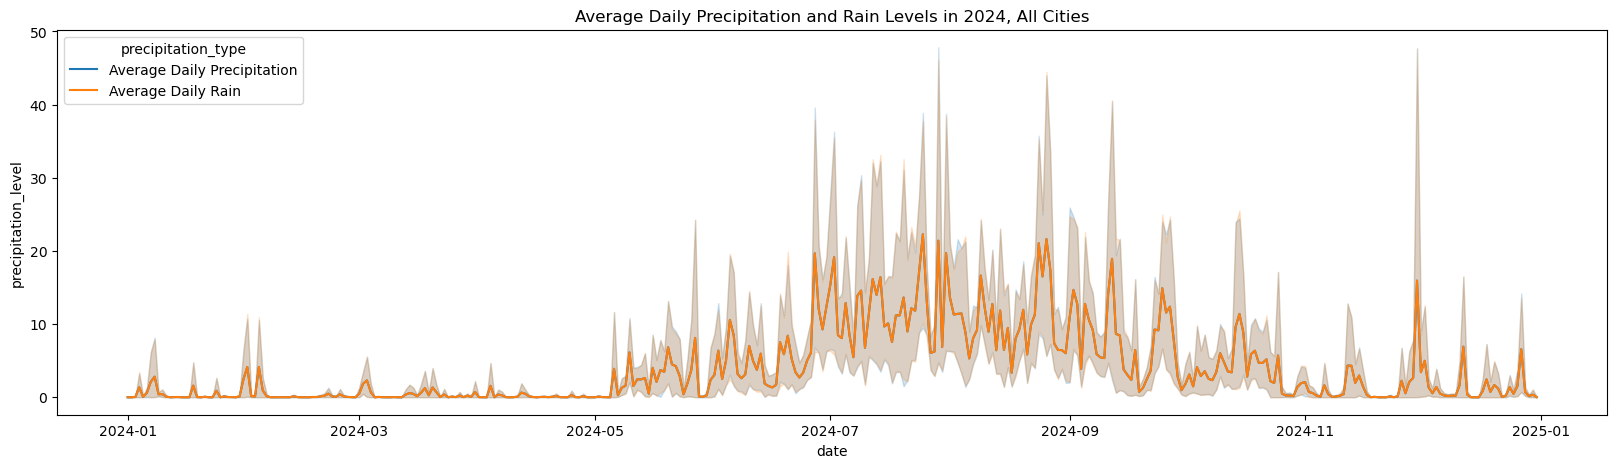

In [59]:
melted_prec_2024 = df_2024.melt(
    id_vars='date',
    value_vars=['precipitation_sum', 'rain_sum'],
    var_name='precipitation_type',
    value_name='precipitation_level',
)

melted_prec_2024['precipitation_type'] = melted_prec_2024['precipitation_type'].replace(
    {'precipitation_sum': 'Average Daily Precipitation', 'rain_sum': 'Average Daily Rain'}
)

fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_prec_2024, x='date', y='precipitation_level', hue='precipitation_type')
plt.title('Average Daily Precipitation and Rain Levels in 2024, All Cities')
plt.show()

In [60]:
fig.savefig(os.path.join(path, 'visualizations','rain_allcities_2024.png'))

#### Daily Maximum Wind Speed and Wind Gusts + Wind Direction

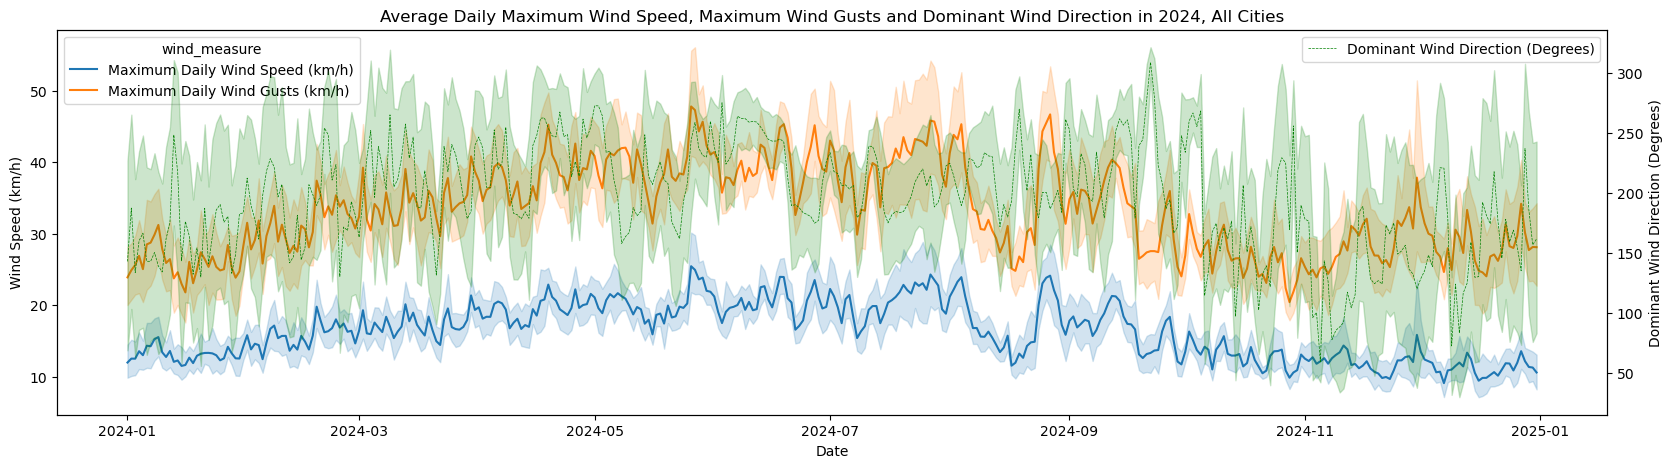

In [62]:
melted_wind_2024 = df_2024.melt(
    id_vars='date',
    value_vars=['wind_speed_10m_max', 'wind_gusts_10m_max'],
    var_name='wind_measure',
    value_name='wind_speed',
)

melted_wind_2024['wind_measure'] = melted_wind_2024['wind_measure'].replace(
    {'wind_speed_10m_max': 'Maximum Daily Wind Speed (km/h)', 'wind_gusts_10m_max': 'Maximum Daily Wind Gusts (km/h)'}
)

fig, ax1 = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_wind_2024, x='date', y='wind_speed', hue='wind_measure')

ax1.set_ylabel('Wind Speed (km/h)')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.set_ylabel('Dominant Wind Direction (Degrees)')
sns.lineplot(
    data=df_2024,
    x='date',
    y='wind_direction_10m_dominant',
    color='green',
    linestyle='--',
    linewidth=0.5,
    label='Dominant Wind Direction (Degrees)',
    ax=ax2,
    
 )
fig.align_ylabels()
plt.title('Average Daily Maximum Wind Speed, Maximum Wind Gusts and Dominant Wind Direction in 2024, All Cities')
plt.show()

In [63]:
fig.savefig(os.path.join(path, 'visualizations','wind_allcities_2024.png'))